In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from datasets import Dataset
from torch.utils.data import DataLoader

torch.manual_seed(42)

In [2]:
# 60 data points: distance (miles) → delivery time (minutes)
# Realistic variance: traffic jams, restaurant wait, parking, time of day
# Base pattern: ~5 min/mile + ~2 min, but real deliveries vary ±30%
distances = torch.tensor([
    # Short trips (0.3 - 2.0 miles) — lots of variance from parking/wait
    [0.3], [0.4], [0.5], [0.6], [0.7],
    [0.8], [0.9], [1.0], [1.0], [1.1],
    [1.2], [1.3], [1.4], [1.5], [1.5],
    [1.7], [1.8], [2.0], [2.0], [2.0],
    # Mid-range trips (2.0 - 6.0 miles) — most common deliveries
    [2.3], [2.5], [2.8], [3.0], [3.0],
    [3.2], [3.5], [3.7], [4.0], [4.0],
    [4.2], [4.5], [4.8], [5.0], [5.0],
    [5.2], [5.5], [5.8], [6.0], [6.0],
    # Long trips (6.0 - 15.0 miles) — highway vs city affects time a lot
    [6.5], [7.0], [7.0], [7.5], [8.0],
    [8.0], [8.5], [9.0], [9.5],[10.0],
    [10.0],[11.0],[11.5],[12.0],[12.0],
    [13.0],[13.5],[14.0],[14.5],[15.0],
], dtype=torch.float32)

times = torch.tensor([
    # Short trips — high variance due to parking, restaurant wait, dense traffic
    [4.20], [4.80], [5.50], [6.30], [7.80],   # 0.3-0.7
    [5.50], [7.20], [6.96], [9.50], [8.30],   # 0.8-1.1 (duplicate 1.0: fast vs slow)
    [8.10], [9.40], [10.20],[9.80],[13.50],    # 1.2-1.5 (last one: long restaurant wait)
    [10.50],[11.80],[12.11],[14.80],[10.20],   # 1.7-2.0 (variance: 12 vs 15 min)
    # Mid-range — traffic light variation, some highway shortcuts
    [13.50],[14.30],[16.00],[16.77],[19.50],   # 2.3-3.0
    [18.10],[19.50],[21.30],[22.00],[25.80],   # 3.2-4.0 (last: rush hour)
    [23.10],[24.50],[26.80],[27.00],[31.20],   # 4.2-5.0
    [28.40],[29.50],[33.10],[32.00],[36.50],   # 5.2-6.0
    # Long trips — highway can be fast, city crawl can be slow
    [34.50],[37.10],[43.00],[39.50],[42.00],   # 6.5-8.0 (7.0 twice: fast vs slow)
    [48.50],[44.30],[46.80],[51.20],[51.80],   # 8.0-10.0
    [57.00],[57.00],[61.50],[62.10],[68.90],   # 10.0-12.0
    [67.30],[72.00],[73.50],[76.80],[77.50],   # 13.0-15.0
], dtype=torch.float32)

In [3]:
model = nn.Sequential(nn.Linear(1,1))

In [4]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)

In [5]:
prev_loss = float('inf')
patience = 50
n_improv = 0

for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(distances)
    loss = loss_function(outputs, times)
    loss.backward()
    optimizer.step()

    if prev_loss - loss.item() < 1e-4:
        n_improv += 1
    else:
        n_improv = 0

    prev_loss = loss.item()

    if n_improv >= patience:
        print(f"Early stop at epoch {epoch + 1}")
        break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: Loss - {loss.item():.4f}")

Epoch 50: Loss - 3.4821
Epoch 100: Loss - 3.3032
Epoch 150: Loss - 3.2202
Epoch 200: Loss - 3.1817
Epoch 250: Loss - 3.1638
Epoch 300: Loss - 3.1555
Epoch 350: Loss - 3.1517
Early stop at epoch 356


In [6]:
def plot_results(model,distances,times):

    model.eval()

    with torch.no_grad():
        predicted_times = model(distances)

    plt.figure(figsize=(8,6))

    plt.plot(distances.numpy(),times.numpy(), color= 'orange', marker='o', linestyle='None', label='Actual Delivery Times')

    plt.plot(distances.numpy(),predicted_times.numpy(), color='green', marker='None', label='Predicted Line')

    plt.title('Actual vs. Predicted Delivery Times')

    plt.xlabel('Distance (miles)')

    plt.ylabel('Time (minutes)')

    plt.legend()

    plt.grid(True)

    plt.show()



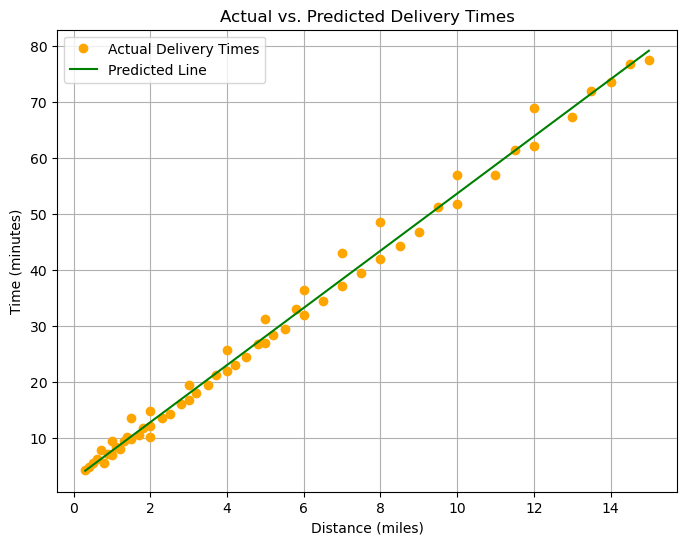

In [7]:
plot_results(model,distances, times)

In [ ]:
distance_input = float(input("Enter distance in miles: "))
distance_predict = torch.tensor([[distance_input]], dtype=torch.float32)

with torch.no_grad():
    predicted_time = model(distance_predict)

print(f"Predicted delivery time for {distance_input} miles: {predicted_time.item():.2f} minutes")